# 04. Analog Selection

## Analog Forecasting이란?
역사적(또는 모델) 데이터에서 **현재 관측 상태와 가장 비슷한 과거 상태(analog)**를 찾아,
그 이후 전개를 예측으로 사용하는 방법이다.

```
관측 초기장 (OISST SSTA, 시점 t)
        ↓
라이브러리에서 가장 비슷한 상태 top-N 선택 (CESM-HR SSTA, 시점 t*)
        ↓  
선택된 analog들의 t*+1, t*+2, ... 을 앙상블 예측으로 사용
```

---

## 이 노트북에서 다루는 것

1. **RMSE 행렬 계산**: 각 OISST 시점 × CESM-HR 라이브러리 멤버 간 유사도
2. **도메인 비교 (핵심 질문)**: Domain a/b/c로 골랐을 때 선택되는 analog가 얼마나 다른가?
3. **N 선택 진단**: 상위 몇 개를 고르는 게 적절한가?
4. **예시 시각화**: 특정 시점의 관측장 vs 상위 analog들

---

## 전제 조건
**03_reducing_modeldrift.ipynb를 먼저 실행해야 한다.**  
필요 파일 (`data/processed/`):
- `cesm_hr_ssta_regridded_domain{a,b,c}.nc`
- `oisst_ssta_v1_domain{a,b,c}.nc` 또는 `oisst_ssta_v2_domain{a,b,c}.nc`

## 0. 임포트 및 설정

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

PROC_DIR = Path("../data/processed")
FIG_DIR  = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

DOMAINS = ["local_wnp", "trop_wnp", "north_pacific"]

# OISST 버전 선택 (v1: anomaly→detrend, v2: detrend→anomaly)
# 03 노트북에서 두 버전을 만들었으므로 여기서 선택
OISST_VERSION = "v1"  # "v1" 또는 "v2"

print(f"OISST version: {OISST_VERSION}")

OISST version: v1


## 1. 데이터 로드 및 확인

CESM-HR SSTA (regridded)와 OISST SSTA가 이제 **동일한 0.25° 규칙 격자** 위에 있다.

In [9]:
# ── 파일 존재 확인 ────────────────────────────────────────────────────
missing = []
for d in DOMAINS:
    for fname in [
        f"cesm_hr_ssta_regridded_{d}.nc",
        f"oisst_ssta_{OISST_VERSION}_{d}.nc",
    ]:
        if not (PROC_DIR / fname).exists():
            missing.append(fname)

if missing:
    raise FileNotFoundError(
        f"다음 파일이 없습니다. 03_reducing_modeldrift.ipynb를 먼저 실행하세요:\n"
        + "\n".join(f"  {f}" for f in missing)
    )

# ── CESM-HR SSTA (라이브러리) 로드 ────────────────────────────────────
# pre-industrial control run (year 250–349), 1200개월
# 이 시계열 전체가 analog 탐색 '라이브러리'가 됨
cesm = {}
for d in DOMAINS:
    ds = xr.open_dataset(PROC_DIR / f"cesm_hr_ssta_regridded_{d}.nc")
    cesm[d] = ds["SSTA"]
    ds.close()

# ── OISST SSTA (관측 초기장) 로드 ─────────────────────────────────────
# 1993–2024, 384개월 → 각 시점이 analog를 찾을 '쿼리'가 됨
oisst = {}
for d in DOMAINS:
    ds = xr.open_dataset(PROC_DIR / f"oisst_ssta_{OISST_VERSION}_{d}.nc")
    oisst[d] = ds["SSTA"]
    ds.close()

# ── 요약 출력 ─────────────────────────────────────────────────────────
print("=" * 55)
print(f"{'도메인':<8} {'CESM (라이브러리)':<22} {'OISST (쿼리)':<20}")
print("-" * 55)
for d in DOMAINS:
    cs = dict(cesm[d].sizes)
    os = dict(oisst[d].sizes)
    # 두 자료의 격자가 동일한지 확인
    lat_ok = np.allclose(cesm[d].lat.values, oisst[d].lat.values)
    lon_ok = np.allclose(cesm[d].lon.values, oisst[d].lon.values)
    grid_check = "✓" if (lat_ok and lon_ok) else "✗ 격자 불일치!"
    print(f"  {d}      {str(cs):<22} {str(os):<20} {grid_check}")
print("=" * 55)

도메인      CESM (라이브러리)           OISST (쿼리)          
-------------------------------------------------------
  a      {'time': 1200, 'lat': 240, 'lon': 320} {'time': 384, 'lat': 240, 'lon': 320} ✓
  b      {'time': 1200, 'lat': 140, 'lon': 240} {'time': 384, 'lat': 140, 'lon': 240} ✓
  c      {'time': 1200, 'lat': 140, 'lon': 240} {'time': 384, 'lat': 140, 'lon': 240} ✓


## 2. RMSE 행렬 계산

### Same-Month 제약 조건
Analog selection에서 **반드시 같은 달(calendar month)끼리만 비교**해야 한다.

이유:
- CESM-HR SSTA는 월별 기후장을 제거했지만, 계절성의 공간 패턴 자체는 달마다 다름
- 1월 관측에 7월 analog를 매칭하면 계절적으로 전혀 다른 상태를 비교하게 됨
- → 물리적으로 의미 없는 analog 선택

구현:
1. 전체 (T_obs × T_lib) RMSE 행렬을 계산
2. 달이 다른 entry를 `np.inf`로 치환 → `argsort`에서 자동으로 뒤로 밀려남

이렇게 하면 각 OISST 시점당 **유효 라이브러리 크기 = T_lib / 12** (예: 1200/12 = 100개/월)

---

### 유사도 지표: 공간 RMSE

$$\\text{RMSE}(i, j) = \\sqrt{\\frac{\\sum_k w_k \\cdot (O_{i,k} - C_{j,k})^2}{\\sum_k w_k}}$$

- $k$ : 공간 격자 인덱스 (유효한 해양 격자만)
- $w_k = \\cos(\\text{lat}_k)$ : **위도별 면적 가중치**
- 값이 **작을수록** 더 유사한 analog

### 효율적 계산: 행렬 분해

$$\\text{RMSE}^2(i,j) = \\frac{\\|O_i\\|^2}{N} + \\frac{\\|C_j\\|^2}{N} - \\frac{2 \\, O_i \\cdot C_j^T}{N}$$

마지막 항 $O \\cdot C^T$ 가 행렬 곱 하나로 처리되므로 전체 행렬을 $O(T_{obs} \\times T_{lib})$ 로 얻는다.

In [10]:
def compute_rmse_matrix(obs_da, lib_da):
    """
    관측(쿼리) DataArray와 라이브러리 DataArray 간의 RMSE 행렬을 계산한다.

    Parameters
    ----------
    obs_da : xr.DataArray  — 관측 SSTA, (time_obs, lat, lon)
    lib_da : xr.DataArray  — 라이브러리 SSTA, (time_lib, lat, lon)

    Returns
    -------
    rmse : np.ndarray, shape (T_obs, T_lib)
        rmse[i, j] = OISST 시점 i와 CESM-HR 라이브러리 시점 j의 공간 RMSE
    valid_mask : np.ndarray, shape (N_spatial,)  — 사용된 해양 격자 마스크
    """
    # ── 위도별 면적 가중치 ──────────────────────────────────────────
    # cos(lat)에 비례하는 격자 면적 가중치
    # 2D로 broadcast: (lat,) → (lat, lon)
    lat_weights = np.cos(np.deg2rad(obs_da.lat.values))  # (n_lat,)
    w_2d = np.broadcast_to(
        lat_weights[:, None], (len(obs_da.lat), len(obs_da.lon))
    ).copy()  # (n_lat, n_lon)

    # ── 데이터 numpy 추출 및 reshape ────────────────────────────────
    obs_vals = obs_da.values   # (T_obs, lat, lon)
    lib_vals = lib_da.values   # (T_lib, lat, lon)
    T_obs, n_lat, n_lon = obs_vals.shape
    T_lib = lib_vals.shape[0]
    N_sp = n_lat * n_lon

    obs_flat = obs_vals.reshape(T_obs, N_sp).astype(np.float64)  # (T_obs, N_sp)
    lib_flat = lib_vals.reshape(T_lib, N_sp).astype(np.float64)  # (T_lib, N_sp)
    w_flat   = w_2d.ravel()                                       # (N_sp,)

    # ── 유효 격자 마스크 ─────────────────────────────────────────────
    # 관측과 라이브러리 모두 NaN이 없는 격자만 사용
    # (NaN은 육지 또는 regrid 경계 외부)
    obs_valid  = np.all(np.isfinite(obs_flat), axis=0)   # (N_sp,)
    lib_valid  = np.all(np.isfinite(lib_flat), axis=0)   # (N_sp,)
    valid_mask = obs_valid & lib_valid                    # 둘 다 유효한 격자

    # 유효 격자만 추출 + 가중치 정규화
    obs_v = obs_flat[:, valid_mask]   # (T_obs, N_valid)
    lib_v = lib_flat[:, valid_mask]   # (T_lib, N_valid)
    w_v   = w_flat[valid_mask]        # (N_valid,)
    w_v   = w_v / w_v.sum()          # 가중치 합이 1이 되도록 정규화

    # ── 가중치 적용: sqrt(w) 곱하면 RMSE = RMS 문제로 변환 ──────────
    # RMSE²(i,j) = Σ_k w_k*(obs[i,k]-lib[j,k])²
    #            = Σ_k (√w_k*obs[i,k] - √w_k*lib[j,k])²
    # → 각 변수에 √w를 곱하면 일반 L2 거리 문제와 같아짐
    sqrt_w   = np.sqrt(w_v)     # (N_valid,)
    obs_w    = obs_v * sqrt_w   # (T_obs, N_valid)
    lib_w    = lib_v * sqrt_w   # (T_lib, N_valid)

    # ── 행렬 분해로 RMSE² 계산 ───────────────────────────────────────
    # RMSE²(i,j) = ||obs_w[i]||² + ||lib_w[j]||² - 2*(obs_w @ lib_w.T)[i,j]
    obs_sq   = np.sum(obs_w**2, axis=1)   # (T_obs,) — 각 관측 시점의 제곱합
    lib_sq   = np.sum(lib_w**2, axis=1)   # (T_lib,) — 각 라이브러리 시점의 제곱합
    cross    = obs_w @ lib_w.T             # (T_obs, T_lib) — 행렬 곱 (빠름)

    # broadcasting으로 전체 행렬 한 번에 계산
    rmse_sq = obs_sq[:, None] + lib_sq[None, :] - 2 * cross

    # 수치 오차로 음수가 생길 수 있으므로 clamp
    rmse = np.sqrt(np.maximum(rmse_sq, 0.0)).astype(np.float32)

    return rmse, valid_mask


print("compute_rmse_matrix 함수 정의 완료")
print(f"예상 RMSE 행렬 크기: (384 obs × 1200 lib) = {384*1200*4/1e6:.1f} MB")

compute_rmse_matrix 함수 정의 완료
예상 RMSE 행렬 크기: (384 obs × 1200 lib) = 1.8 MB


In [11]:
# ── 도메인별 RMSE 행렬 계산 ───────────────────────────────────────────
rmse_matrices = {}  # {도메인: (T_obs, T_lib) RMSE 행렬}
valid_masks   = {}  # {도메인: 유효 격자 마스크}

for d in DOMAINS:
    print(f"domain {d} RMSE 행렬 계산 중...", end=" ", flush=True)
    rmse, vmask = compute_rmse_matrix(oisst[d], cesm[d])
    rmse_matrices[d] = rmse
    valid_masks[d]   = vmask
    n_valid = vmask.sum()
    lat_sz, lon_sz = oisst[d].sizes["lat"], oisst[d].sizes["lon"]
    print(f"완료  {rmse.shape}  유효 격자: {n_valid:,}/{lat_sz*lon_sz:,}  "
          f"({n_valid/(lat_sz*lon_sz)*100:.1f}%)")

print("\n전체 RMSE 행렬 계산 완료")

domain a RMSE 행렬 계산 중... 완료  (384, 1200)  유효 격자: 40,119/76,800  (52.2%)
domain b RMSE 행렬 계산 중... 완료  (384, 1200)  유효 격자: 26,735/33,600  (79.6%)
domain c RMSE 행렬 계산 중... 완료  (384, 1200)  유효 격자: 5,829/33,600  (17.3%)

전체 RMSE 행렬 계산 완료


In [12]:
# ── Same-Month 마스킹 ─────────────────────────────────────────────────
# 달이 다른 (OISST 시점, CESM-HR 시점) 쌍을 np.inf로 치환한다.
# 이후 argsort를 쓰면 inf 항목은 자동으로 순위 뒤쪽으로 밀려나므로
# top-N 선택 시 자연스럽게 same-month analog만 고르게 된다.

# OISST time axis에서 month 추출 (datetime64 → 정수 1~12)
month_obs = oisst["a"].time.dt.month.values  # (T_obs,) — 모든 도메인 공통

# CESM-HR time axis에서 month 추출 (cftime → xarray .dt.month 지원)
# 모든 도메인은 같은 라이브러리이므로 domain a에서만 추출
month_lib = cesm["a"].time.dt.month.values   # (T_lib,)

# Same-month 마스크: (T_obs, T_lib) — True이면 같은 달
# month_obs[:, None]: (T_obs, 1) broadcast
# month_lib[None, :]: (1, T_lib) broadcast
same_month = (month_obs[:, None] == month_lib[None, :])  # (T_obs, T_lib)

print(f"month_obs 예시: {month_obs[:6]}  ...  {month_obs[-3:]}")
print(f"month_lib 예시: {month_lib[:6]}  ...  {month_lib[-3:]}")
print(f"same_month shape: {same_month.shape}")
print(f"True(같은 달) 비율: {same_month.mean():.4f}  (≈ 1/12 = {1/12:.4f})")
print(f"→ 각 OISST 시점당 유효 라이브러리 크기: {int(same_month.sum(axis=1).mean())}개/월")

# RMSE 행렬에 마스크 적용: 다른 달은 inf로 치환
for d in DOMAINS:
    rmse_matrices[d] = np.where(same_month, rmse_matrices[d], np.inf)

# 검증: inf가 아닌 entry 수 확인
for d in DOMAINS:
    n_valid = np.isfinite(rmse_matrices[d]).sum()
    n_total = rmse_matrices[d].size
    print(f"domain {d}: 유효 entry {n_valid:,} / {n_total:,}  ({n_valid/n_total*100:.1f}%)")


month_obs 예시: [1 2 3 4 5 6]  ...  [10 11 12]
month_lib 예시: [2 3 4 5 6 7]  ...  [11 12  1]
same_month shape: (384, 1200)
True(같은 달) 비율: 0.0833  (≈ 1/12 = 0.0833)
→ 각 OISST 시점당 유효 라이브러리 크기: 100개/월
domain a: 유효 entry 38,400 / 460,800  (8.3%)
domain b: 유효 entry 38,400 / 460,800  (8.3%)
domain c: 유효 entry 38,400 / 460,800  (8.3%)


## 3. 도메인 비교: a/b/c로 고르면 analog가 얼마나 다른가?

Domain을 좁히면(a → c) 더 좁은 공간 패턴으로 analog를 선택하게 된다.
이 섹션에서는 세 가지 관점에서 도메인별 차이를 정량화한다:

1. **RMSE 분포 비교**: 도메인에 따라 평균 RMSE가 얼마나 다른가?
2. **Top-N 중복율 (Jaccard)**: 상위 N개를 골랐을 때 얼마나 같은 analog를 선택하는가?
3. **순위 상관 (Rank correlation)**: 도메인 간 library ranking이 얼마나 일치하는가?

C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\154559944.py:41: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\154559944.py:41: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\154559944.py:41: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\154559944.py:41: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\154559944.py:41: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\154559944.py:41: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) D

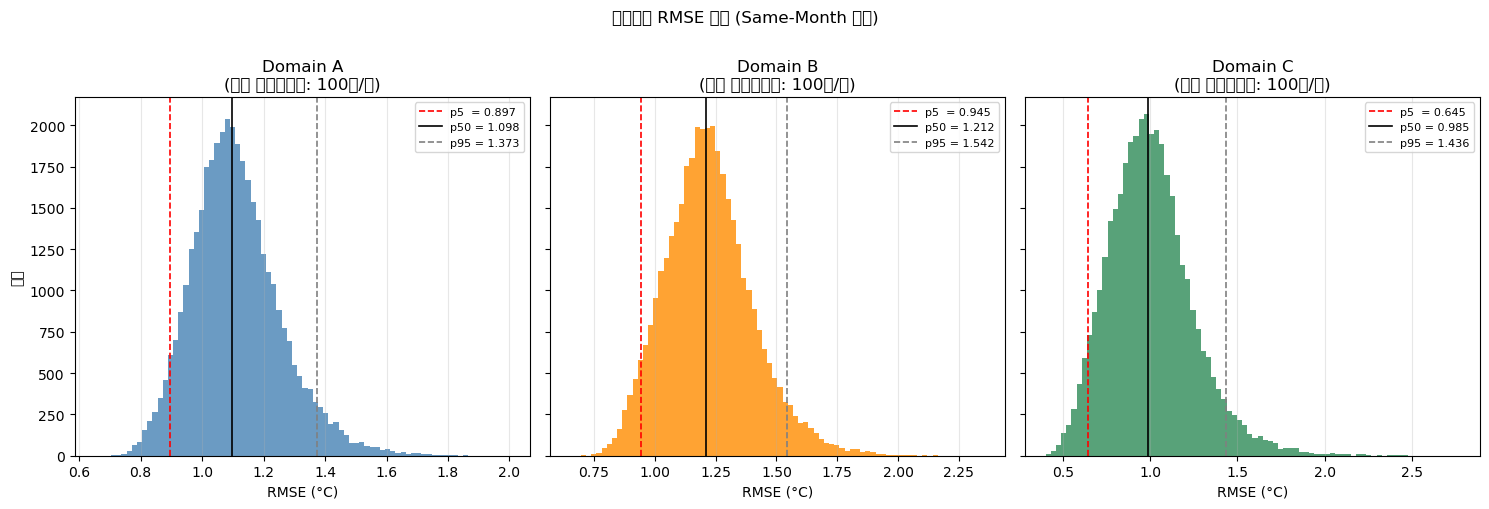


=== RMSE 통계 (same-month 쌍) ===
도메인         mean     std      p5     p50     p95
---------------------------------------------
  a       1.111   0.145   0.897   1.098   1.373
  b       1.223   0.181   0.945   1.212   1.542
  c       1.005   0.245   0.645   0.985   1.436


In [13]:
# ── 3.1 RMSE 분포 비교 (same-month 쌍만) ─────────────────────────────
# inf(다른 달)를 제외하고 같은 달끼리의 RMSE만 histogram으로 시각화

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = {"a": "steelblue", "b": "darkorange", "c": "seagreen"}

stats_table = []

for i, d in enumerate(DOMAINS):
    # isfinite로 same-month 쌍만 추출 (inf 제외)
    rmse = rmse_matrices[d][np.isfinite(rmse_matrices[d])]

    ax = axes[i]
    ax.hist(rmse, bins=80, color=colors[d], edgecolor="none", alpha=0.8)
    ax.axvline(np.percentile(rmse, 5),  color="red",   ls="--", lw=1.2,
               label=f"p5  = {np.percentile(rmse, 5):.3f}")
    ax.axvline(np.percentile(rmse, 50), color="black", ls="-",  lw=1.2,
               label=f"p50 = {np.percentile(rmse, 50):.3f}")
    ax.axvline(np.percentile(rmse, 95), color="gray",  ls="--", lw=1.2,
               label=f"p95 = {np.percentile(rmse, 95):.3f}")

    domain_info = dict(oisst[d].sizes)
    n_per_month = int(same_month.sum(axis=1).mean())
    ax.set_title(f"Domain {d.upper()}\n"
    ax.set_xlabel("RMSE (°C)")
    if i == 0: ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="x")

    stats_table.append({
        "domain": d,
        "mean"  : rmse.mean(),
        "std"   : rmse.std(),
        "p5"    : np.percentile(rmse, 5),
        "p50"   : np.percentile(rmse, 50),
        "p95"   : np.percentile(rmse, 95),
    })

plt.suptitle("RMSE Distribution by Domain (Same-Month Pairs Only)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "analog_rmse_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== RMSE 통계 (same-month 쌍) ===")
print(f"{'도메인':<8} {'mean':>7} {'std':>7} {'p5':>7} {'p50':>7} {'p95':>7}")
print("-" * 45)
for s in stats_table:
    print(f"  {s['domain']}     {s['mean']:7.3f} {s['std']:7.3f} "
          f"{s['p5']:7.3f} {s['p50']:7.3f} {s['p95']:7.3f}")


C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2098458463.py:46: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2098458463.py:46: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2098458463.py:46: UserWarning: Glyph 47751 (\N{HANGUL SYLLABLE MYEOC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2098458463.py:46: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2098458463.py:46: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2098458463.py:46: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing

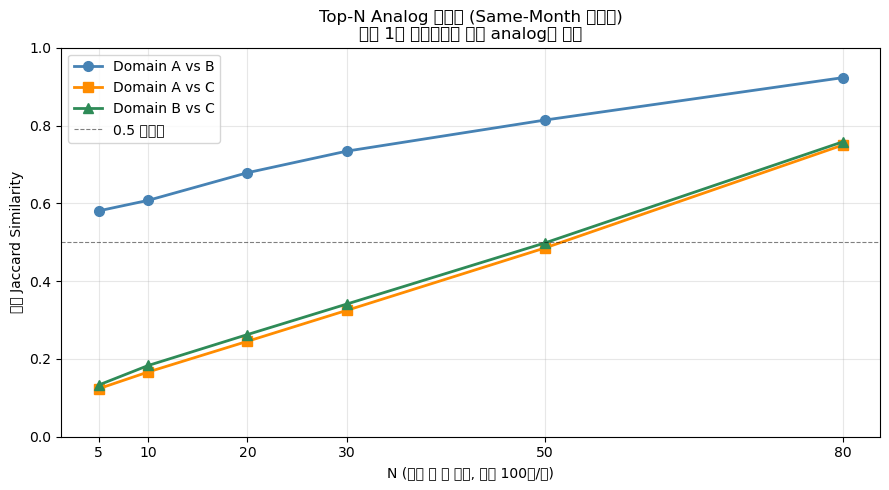


=== Jaccard 수치 (same-month, 유효 라이브러리 100개/월) ===
    N  AvsB  AvsC  BvsC
    5    0.581    0.123    0.133
   10    0.608    0.166    0.183
   20    0.679    0.245    0.263
   30    0.734    0.325    0.341
   50    0.814    0.485    0.498
   80    0.923    0.750    0.758


In [14]:
# ── 3.2 Top-N 중복율 (Jaccard Similarity) — Same-Month 기준 ──────────
# argsort에서 inf는 뒤로 밀리므로 top-N은 자동으로 same-month analog만 포함됨
# N 범위를 N_PER_MONTH 이하로 제한 (유효 라이브러리 크기 내)

N_values = [5, 10, 20, 30, 50, min(80, n_per_month)]
pairs    = [("local_wnp","trop_wnp"), ("local_wnp","north_pacific"), ("trop_wnp","north_pacific")]

jaccard_results = {pair: [] for pair in pairs}

for N in N_values:
    top_N = {}
    for d in DOMAINS:
        # argsort: same-month (finite) 값이 앞, inf(다른 달)가 뒤 → [:N]은 항상 same-month
        top_N[d] = np.argsort(rmse_matrices[d], axis=1)[:, :N]  # (T_obs, N)

    T_obs = top_N[DOMAINS[0]].shape[0]

    for (d1, d2) in pairs:
        jaccard_per_t = []
        for t in range(T_obs):
            s1 = set(top_N[d1][t])
            s2 = set(top_N[d2][t])
            j  = len(s1 & s2) / len(s1 | s2)
            jaccard_per_t.append(j)
        jaccard_results[(d1, d2)].append(np.mean(jaccard_per_t))

fig, ax = plt.subplots(figsize=(9, 5))

pair_colors  = [("a","b","steelblue"), ("a","c","darkorange"), ("b","c","seagreen")]
pair_markers = ["o", "s", "^"]

for (d1, d2, col), mk in zip(pair_colors, pair_markers):
    ax.plot(N_values, jaccard_results[(d1, d2)],
            color=col, marker=mk, lw=2, ms=7,
            label=f"Domain {d1.upper()} vs {d2.upper()}")

ax.axhline(0.5, color="black", ls="--", lw=0.8, alpha=0.5, label="0.5 reference")
ax.set_xlabel(f"N (Top-N Selected, max {n_per_month}/month)")
ax.set_ylabel("Mean Jaccard Similarity")
ax.set_title("Top-N Analog Overlap Rate (Within Same-Month)
Values close to 1 indicate consistent analog selection")
ax.set_ylim(0, 1)
ax.set_xticks(N_values)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "analog_jaccard_similarity.png", dpi=150)
plt.show()

print(f"\n=== Jaccard 수치 (same-month, 유효 라이브러리 {n_per_month}개/월) ===")
print(f"{'N':>5}", end="")
for (d1,d2) in pairs:
    print(f"  {d1.upper()}vs{d2.upper()}", end="")
print()
for i, N in enumerate(N_values):
    print(f"{N:>5}", end="")
    for (d1,d2) in pairs:
        print(f"  {jaccard_results[(d1,d2)][i]:7.3f}", end="")
    print()


C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2422198348.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2422198348.py:59: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2422198348.py:59: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2422198348.py:59: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\2422198348.py:59: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layou

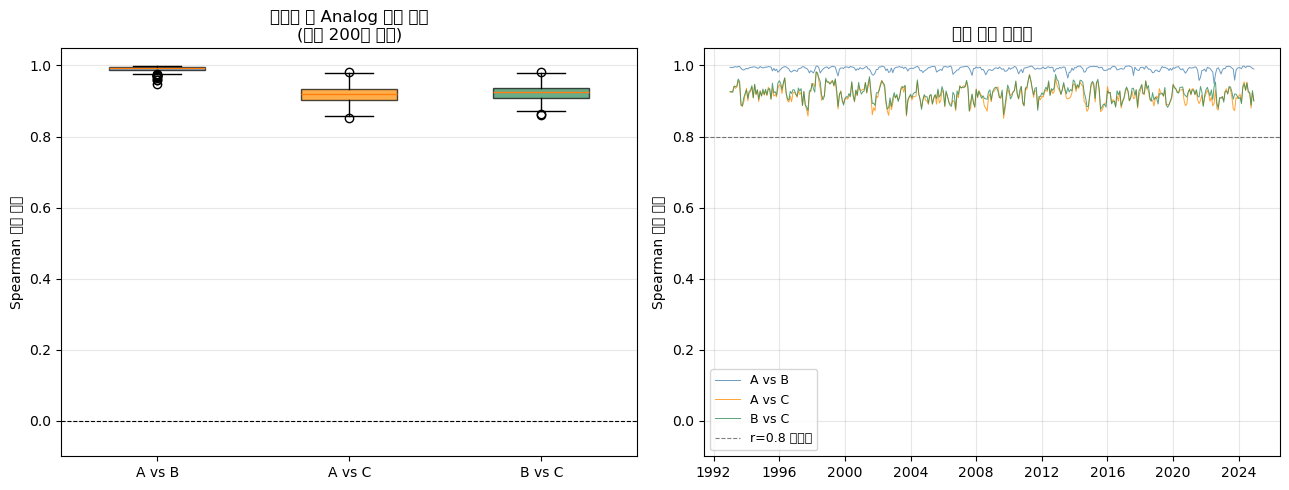


=== Spearman 순위 상관 요약 ===
  A vs B: mean=0.991  min=0.948  max=0.999  |r<0.5|=0개 시점
  A vs C: mean=0.918  min=0.851  max=0.983  |r<0.5|=0개 시점
  B vs C: mean=0.923  min=0.861  max=0.982  |r<0.5|=0개 시점


In [15]:
# ── 3.3 도메인 간 Analog 순위 상관 ───────────────────────────────────
# 각 OISST 시점에서 도메인 X와 Y의 CESM-HR 라이브러리 순위가 얼마나 일치하는가?
# Spearman 순위 상관: 1이면 완전히 같은 순서, 0이면 무관, -1이면 반대
#
# ⚠️ 전체 T_lib에 대한 순위 상관은 무거우므로 상위 200개만 사용

from scipy.stats import spearmanr

TOP_K = 200   # 순위 상관 계산에 쓸 상위 개수 (전체 T_lib 대신)

rank_corr_results = {}  # {(d1, d2): OISST 시점별 Spearman r 배열}

for (d1, d2) in pairs:
    T_obs = rmse_matrices[d1].shape[0]
    corrs = []

    for t in range(T_obs):
        # 상위 TOP_K analog의 RMSE 값 추출 (도메인 d1 기준으로 필터)
        top_idx = np.argsort(rmse_matrices[d1][t])[:TOP_K]
        rmse_d1 = rmse_matrices[d1][t, top_idx]
        rmse_d2 = rmse_matrices[d2][t, top_idx]

        r, _ = spearmanr(rmse_d1, rmse_d2)
        corrs.append(r)

    rank_corr_results[(d1, d2)] = np.array(corrs)

# ── 시각화: 박스플롯 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 박스플롯: 전체 분포
ax = axes[0]
data   = [rank_corr_results[p] for p in pairs]
labels = [f"{d1.upper()} vs {d2.upper()}" for (d1,d2) in pairs]
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
for patch, col in zip(bp["boxes"], ["steelblue", "darkorange", "seagreen"]):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax.axhline(0, color="black", ls="--", lw=0.8)
ax.set_ylabel("Spearman Rank Correlation")
ax.set_title(f"Cross-Domain Analog Rank Correlation
(Top-{TOP_K})")
ax.set_ylim(-0.1, 1.05)
ax.grid(alpha=0.3, axis="y")

# 시계열: 시간에 따른 순위 상관 변화
ax = axes[1]
times = oisst["a"].time.values  # OISST 시간축
for (d1,d2), col in zip(pairs, ["steelblue","darkorange","seagreen"]):
    ax.plot(times, rank_corr_results[(d1,d2)],
            color=col, lw=0.7, alpha=0.8,
            label=f"{d1.upper()} vs {d2.upper()}")
ax.axhline(0.8, color="black", ls="--", lw=0.8, alpha=0.5, label="r=0.8 reference")
ax.set_ylabel("Spearman Rank Correlation")
ax.set_title("순위 상관 시계열")
ax.set_ylim(-0.1, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "analog_rank_correlation.png", dpi=150)
plt.show()

print("\n=== Spearman 순위 상관 요약 ===")
for (d1,d2) in pairs:
    r = rank_corr_results[(d1,d2)]
    print(f"  {d1.upper()} vs {d2.upper()}: mean={r.mean():.3f}  "
          f"min={r.min():.3f}  max={r.max():.3f}  "
          f"|r<0.5|={(r<0.5).sum()}개 시점")

## 4. N 선택 진단

### N을 어떻게 결정하는가?

N이 너무 작으면 → 좋은 analog를 놓칠 수 있고 앙상블 분산이 작아진다  
N이 너무 크면  → 나쁜 analog(RMSE 큰 것)까지 포함되어 예측 품질 저하

**진단 방법**:
1. **Scree plot**: 정렬된 RMSE 곡선에서 'elbow(꺾임점)' 찾기
2. **상대 RMSE gap**: 1위 analog 대비 N위 analog의 RMSE 비율
3. **Score ratio**: `RMSE_rank_N / RMSE_rank_1` 가 일정 임계값(예: 1.5) 초과 시 N 결정

C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\1488993415.py:48: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\1488993415.py:48: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\1488993415.py:48: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\1488993415.py:48: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\1488993415.py:48: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\1488993415.py:48: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from fon

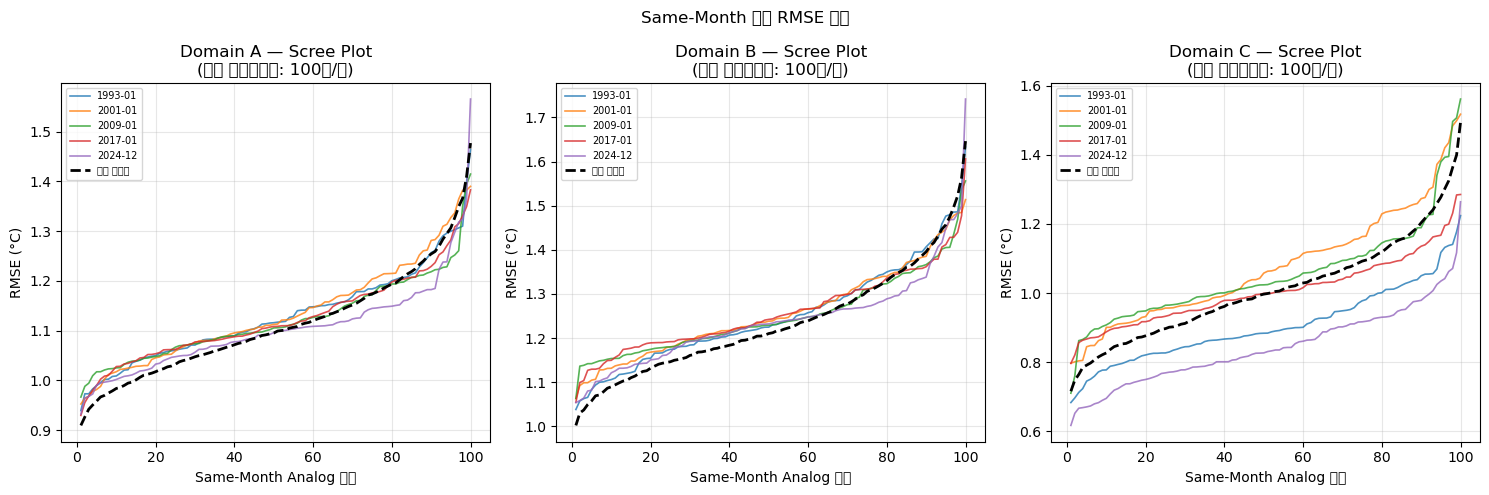

라이브러리 100년 기준: 달당 100개 analog 후보
→ N은 이 범위 안에서 결정해야 함


In [17]:
# ── 4.1 Scree plot: 정렬된 RMSE 곡선 (same-month 기준) ────────────────
# argsort는 inf를 맨 뒤에 두므로, 앞쪽 N_PER_MONTH개만 보면 same-month analog다.

# 각 달의 라이브러리 크기 (CESM-HR 100년 × 12달 = 100개/달)
n_per_month = int(same_month.sum(axis=1).mean())
SHOW_TOP    = n_per_month   # 전체 same-month 범위 표시

T_obs = rmse_matrices["c"].shape[0]
sample_t_indices = [
    0,
    T_obs // 4,
    T_obs // 2,
    3 * T_obs // 4,
    T_obs - 1,
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for i, d in enumerate(DOMAINS):
    ax = axes[i]
    for t_idx in sample_t_indices:
        row = rmse_matrices[d][t_idx]
        # argsort: inf가 뒤로 가고 유한값(same-month)이 앞으로 옴
        sorted_rmse = np.sort(row)[:SHOW_TOP]
        # 유한한 값만 (inf가 섞이면 곡선이 왜곡됨)
        finite_mask  = np.isfinite(sorted_rmse)
        x = np.arange(1, SHOW_TOP + 1)[finite_mask]
        y = sorted_rmse[finite_mask]
        t_label = str(oisst[d].time.values[t_idx])[:7]
        ax.plot(x, y, lw=1.2, alpha=0.8, label=t_label)

    # 전체 시점 중앙값 곡선
    all_sorted = np.sort(rmse_matrices[d], axis=1)[:, :SHOW_TOP]
    median_curve = np.nanmedian(
        np.where(np.isfinite(all_sorted), all_sorted, np.nan),
        axis=0,
    )
    ax.plot(range(1, SHOW_TOP + 1), median_curve,
            color="black", lw=2, ls="--", label="Overall Median")

    ax.set_xlabel("Same-Month Analog Rank")
    ax.set_ylabel("RMSE (°C)")
    ax.set_title(f"Domain {d.upper()} — Scree Plot
(Valid library: {n_per_month} members/month)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("Same-Month Sorted RMSE Curves", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "analog_scree_plot.png", dpi=150)
plt.show()

print(f"라이브러리 100년 기준: 달당 {n_per_month}개 analog 후보")
print("→ N은 이 범위 안에서 결정해야 함")


C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\3250091013.py:49: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\3250091013.py:49: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\3250091013.py:49: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\3250091013.py:49: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\3250091013.py:49: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\3250091013.py:49: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from 

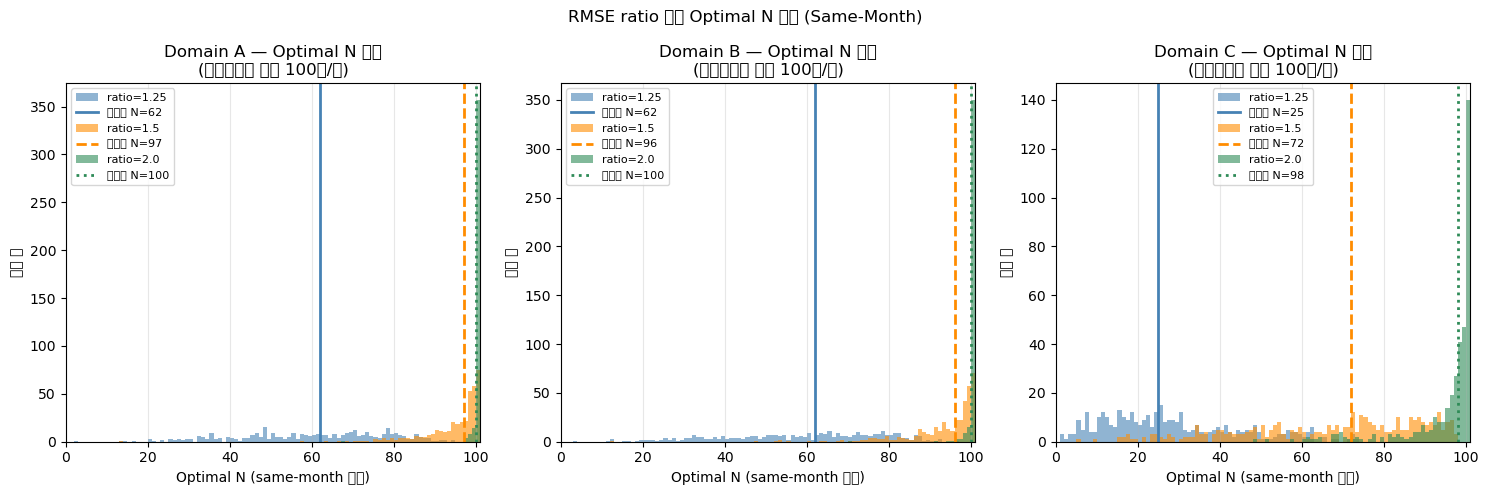


=== RMSE ratio 기준 Optimal N 요약 (중앙값) ===
임계값           Domain A  Domain B  Domain C
ratio=1.25           62         62         25
ratio=1.5            97         96         72
ratio=2.0           100        100         98


In [18]:
# ── 4.2 N 선택 기준: RMSE ratio 분석 (same-month 기준) ────────────────
# ratio = RMSE(rank_N) / RMSE(rank_1)
# rank_1~rank_N_PER_MONTH 사이에서만 의미있는 값 (나머지는 inf)

# N 후보: 유효 라이브러리(N_PER_MONTH)의 범위 안으로 제한
N_MAX = n_per_month   # 예: 100
RATIO_THRESHOLDS = [1.25, 1.5, 2.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, d in enumerate(DOMAINS):
    ax = axes[i]

    # same-month analog만 정렬 (inf는 argsort에서 자동으로 뒤로)
    rmse_sorted = np.sort(rmse_matrices[d], axis=1)[:, :N_MAX]  # (T_obs, N_MAX)

    # best_rmse: rank-1 RMSE (항상 finite, same-month 보장)
    best_rmse = rmse_sorted[:, 0:1]   # (T_obs, 1)

    # ratio 행렬: (T_obs, N_MAX)
    ratio_matrix = rmse_sorted / np.maximum(best_rmse, 1e-6)

    for thresh, col, ls in zip(
        RATIO_THRESHOLDS,
        ["steelblue", "darkorange", "seagreen"],
        ["-", "--", ":"]
    ):
        # ratio > threshold가 처음 되는 N (= 이 N부터 품질 저하)
        exceeds    = ratio_matrix > thresh                           # (T_obs, N_MAX)
        optimal_N  = np.argmax(exceeds, axis=1)                     # (T_obs,)
        # 끝까지 안 넘으면 argmax=0 → N_MAX로 보정
        never      = ~exceeds.any(axis=1)
        optimal_N[never] = N_MAX

        ax.hist(optimal_N, bins=range(1, N_MAX + 2), alpha=0.6,
                color=col, label=f"ratio={thresh}")
        med_N = int(np.median(optimal_N))
        ax.axvline(med_N, color=col, ls=ls, lw=2,
                   label=f"중앙값 N={med_N}")

    ax.set_xlabel("Optimal N (Same-Month Basis)")
    ax.set_ylabel("# Time Steps")
    ax.set_title(f"Domain {d.upper()} — Optimal N 분포\n(라이브러리 최대 {N_MAX}개/월)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="x")
    ax.set_xlim(0, N_MAX + 1)

plt.suptitle("Optimal N Distribution by RMSE Ratio (Same-Month)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "analog_optimal_N.png", dpi=150)
plt.show()

print("\n=== RMSE ratio 기준 Optimal N 요약 (중앙값) ===")
print(f"{'임계값':<12}", end="")
for d in DOMAINS: print(f"  Domain {d.upper()}", end="")
print()
for thresh in RATIO_THRESHOLDS:
    print(f"ratio={thresh:<6}", end="")
    for d in DOMAINS:
        rmse_sorted  = np.sort(rmse_matrices[d], axis=1)[:, :N_MAX]
        best_rmse    = rmse_sorted[:, 0:1]
        ratio_matrix = rmse_sorted / np.maximum(best_rmse, 1e-6)
        exceeds      = ratio_matrix > thresh
        opt_N        = np.argmax(exceeds, axis=1)
        opt_N[~exceeds.any(axis=1)] = N_MAX
        print(f"  {int(np.median(opt_N)):>9}", end="")
    print()


## 5. 예시: 특정 시점의 Top-N Analog 시각화

특정 OISST 시점의 관측 SSTA와 각 도메인에서 고른 best analog(rank 1)를 나란히 비교한다.

In [19]:
# ── 파라미터 설정 ─────────────────────────────────────────────────────
# 시각화할 OISST 시점 선택 (날짜로 지정)
TARGET_DATE = "2011-03"   # ← 원하는 날짜로 변경
SHOW_N      = 3            # 상위 몇 개 analog를 보여줄지 (domain c 기준)

# 날짜 → 인덱스 변환
times_c = [str(t)[:7] for t in oisst["c"].time.values]
if TARGET_DATE not in times_c:
    raise ValueError(f"{TARGET_DATE}가 OISST 데이터에 없습니다. 형식: 'YYYY-MM'")
t_idx = times_c.index(TARGET_DATE)

print(f"대상 시점: {TARGET_DATE} (인덱스: {t_idx})")

# 각 도메인에서 best analog의 라이브러리 인덱스와 RMSE
print("\n=== Best Analog (domain c 기준) ===")
for rank in range(1, SHOW_N + 1):
    lib_idx = np.argsort(rmse_matrices["c"][t_idx])[rank - 1]
    rmse_val = rmse_matrices["c"][t_idx, lib_idx]
    print(f"  rank {rank}: lib index {lib_idx}  RMSE = {rmse_val:.4f} °C")

대상 시점: 2011-03 (인덱스: 218)

=== Best Analog (domain c 기준) ===
  rank 1: lib index 73  RMSE = 0.9074 °C
  rank 2: lib index 385  RMSE = 0.9428 °C
  rank 3: lib index 1069  RMSE = 0.9755 °C


C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\73256331.py:37: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\73256331.py:37: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\73256331.py:38: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / f"analog_example_{TARGET_DATE.replace('-','')}_domain{d}.png", dpi=150)
C:\Users\dnjst\AppData\Local\Temp\ipykernel_21020\73256331.py:38: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / f"analog_example_{TARGET_DATE.replace('-','')}_domain{d}.png", dpi=150)
c:\Users\dnjst\miniconda3\envs\geo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font

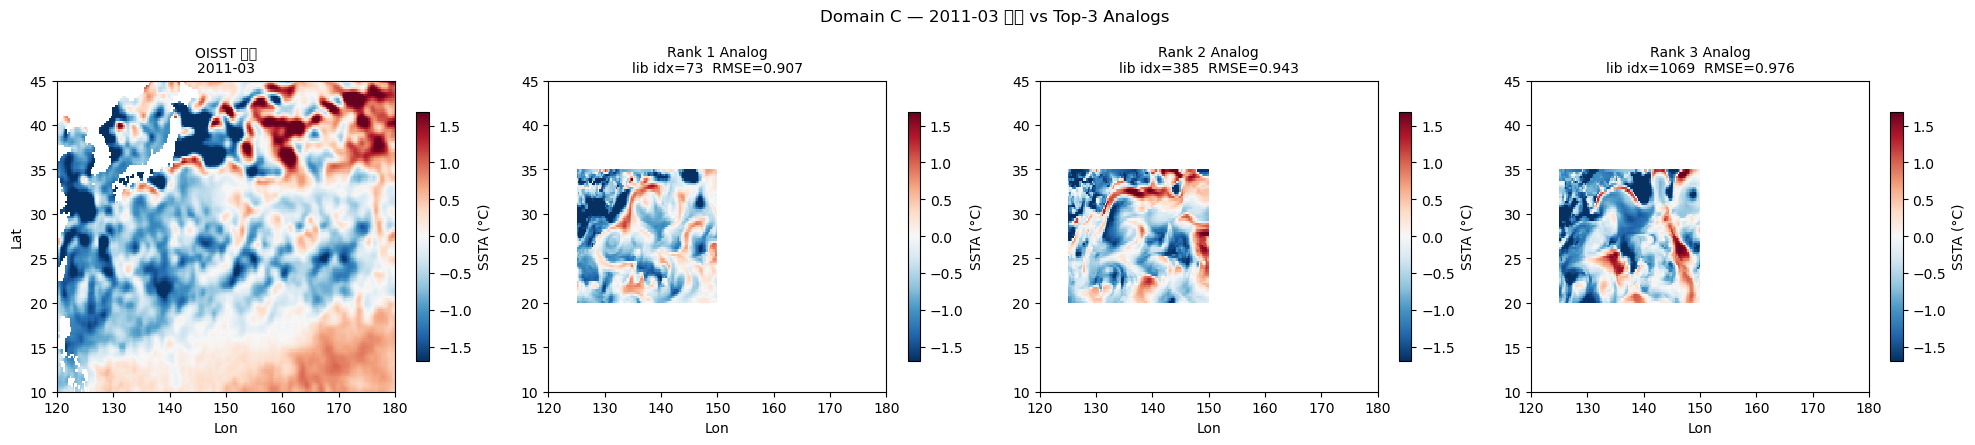

In [20]:
# ── 시각화: 관측 vs Top-3 Analogs (domain c 기준) ───────────────────
d = "north_pacific"   # 작은 도메인으로 시각화
top_indices = np.argsort(rmse_matrices[d][t_idx])[:SHOW_N]

n_cols = SHOW_N + 1  # 관측 + top-N
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4.5))

# 색상 범위 통일
obs_snap = oisst[d].isel(time=t_idx).values
vmax = np.nanpercentile(np.abs(obs_snap), 95)

# 관측 초기장
ax = axes[0]
im = ax.pcolormesh(
    oisst[d].lon.values, oisst[d].lat.values, obs_snap,
    cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto",
)
plt.colorbar(im, ax=ax, label="SSTA (°C)", shrink=0.8)
ax.set_title(f"OISST Observation
{TARGET_DATE}", fontsize=10)
ax.set_xlabel("Lon"); ax.set_ylabel("Lat")

# Top-N Analog
for rank, lib_idx in enumerate(top_indices):
    ax = axes[rank + 1]
    analog_snap = cesm[d].isel(time=lib_idx).values
    rmse_val    = rmse_matrices[d][t_idx, lib_idx]

    im = ax.pcolormesh(
        cesm[d].lon.values, cesm[d].lat.values, analog_snap,
        cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto",
    )
    plt.colorbar(im, ax=ax, label="SSTA (°C)", shrink=0.8)
    ax.set_title(f"Rank {rank+1} Analog\nlib idx={lib_idx}  RMSE={rmse_val:.3f}", fontsize=10)
    ax.set_xlabel("Lon")

plt.suptitle(f"Domain {d.upper()} — {TARGET_DATE} Observation vs Top-{SHOW_N} Analogs", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / f"analog_example_{TARGET_DATE.replace('-','')}_domain{d}.png", dpi=150)
plt.show()

In [21]:
# ── 도메인 간 Best Analog 비교: 같은 시점에서 어떤 analog를 고르는가? ──
# 도메인 a/b/c의 best analog가 서로 다른지 확인

print(f"=== {TARGET_DATE} 시점의 도메인별 Best Analog (rank 1~5) ===")
print(f"{'rank':<6}", end="")
for d in DOMAINS:
    print(f"  Domain {d.upper()} (lib_idx, RMSE)", end="")
print()

for rank in range(1, 6):
    print(f"{rank:<6}", end="")
    for d in DOMAINS:
        lib_idx  = np.argsort(rmse_matrices[d][t_idx])[rank - 1]
        rmse_val = rmse_matrices[d][t_idx, lib_idx]
        print(f"  ({lib_idx:4d}, {rmse_val:.3f})         ", end="")
    print()

# 도메인 a/c의 top-20 overlap 확인
for N_check in [10, 20, 50]:
    top_a = set(np.argsort(rmse_matrices["a"][t_idx])[:N_check])
    top_b = set(np.argsort(rmse_matrices["b"][t_idx])[:N_check])
    top_c = set(np.argsort(rmse_matrices["c"][t_idx])[:N_check])
    overlap_abc = len(top_a & top_b & top_c)
    print(f"\nTop-{N_check}: a∩b∩c = {overlap_abc}개 공통 analog")

=== 2011-03 시점의 도메인별 Best Analog (rank 1~5) ===
rank    Domain A (lib_idx, RMSE)  Domain B (lib_idx, RMSE)  Domain C (lib_idx, RMSE)
1       ( 265, 1.040)           ( 265, 1.141)           (  73, 0.907)         
2       (1009, 1.048)           ( 325, 1.176)           ( 385, 0.943)         
3       ( 109, 1.066)           ( 781, 1.189)           (1069, 0.976)         
4       ( 781, 1.074)           ( 109, 1.192)           ( 781, 0.988)         
5       (1033, 1.078)           (1009, 1.205)           (  85, 0.992)         

Top-10: a∩b∩c = 2개 공통 analog

Top-20: a∩b∩c = 8개 공통 analog

Top-50: a∩b∩c = 35개 공통 analog


## 6. 해석 가이드

### 도메인 선택 판단 기준

| Jaccard (N=20) | 판단 |
|---|---|
| > 0.7 | 도메인 차이가 거의 없음 → 어느 도메인을 써도 비슷 |
| 0.4–0.7 | 적당한 차이 → 도메인별 앙상블 비교 가치 있음 |
| < 0.4 | 매우 다른 analog를 고름 → 도메인 선택이 예측에 큰 영향 |

### N 선택 가이드

| RMSE ratio 임계값 | 의미 | 권장 상황 |
|---|---|---|
| 1.25 | Best analog의 25% 이내 | 보수적 (고품질 analog만) |
| 1.5  | Best analog의 50% 이내 | 일반적으로 많이 쓰임 |
| 2.0  | Best analog의 2배 이내 | 앙상블 다양성 확보 |

### 다음 단계
- `05_analog_forecast.ipynb`: 선택된 analog의 t+1, t+2, ... lead-time SST를 앙상블 예측으로 구성
- Cross-validation: 실제 관측(OISST future)과 예측을 비교해 skill score 계산 후 domain/N 최적화